IMPORTING PACKAGES AND Identify and handle outliers

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv('Wholesale customers data.csv')

print(df.head())

# 1. Identify and handle outliers in three numerical columns

# Select three numerical columns (change as per your dataset)
numerical_cols = ["Fresh", "Milk", "Grocery"]

for col in numerical_cols:
    # Detect outliers using IQR (optional for info)
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"Outliers in {col} (IQR method): {len(outliers)} rows")
    
    # Cap outliers using 5th and 95th percentiles
    lower_cap = df[col].quantile(0.05)
    upper_cap = df[col].quantile(0.95)
    df[col] = np.where(df[col] < lower_cap, lower_cap, df[col])
    df[col] = np.where(df[col] > upper_cap, upper_cap, df[col])
    
    print(f"{col} values capped between {lower_cap} and {upper_cap}\n")



   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0        2       3  12669  9656     7561     214              2674        1338
1        2       3   7057  9810     9568    1762              3293        1776
2        2       3   6353  8808     7684    2405              3516        7844
3        1       3  13265  1196     4221    6404               507        1788
4        2       3  22615  5410     7198    3915              1777        5185
Outliers in Fresh (IQR method): 20 rows
Fresh values capped between 401.9000000000001 and 36818.5

Outliers in Milk (IQR method): 28 rows
Milk values capped between 593.75 and 16843.399999999947

Outliers in Grocery (IQR method): 24 rows
Grocery values capped between 851.4500000000002 and 24033.499999999967



Determine the frequency distribution

In [4]:
df[df["Fresh"] < 100]

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen


In [5]:

# 2. Frequency distribution for two categorical columns

# Select two categorical columns (update based on your dataset)
cat_cols = ['Channel', 'Region']

for col in cat_cols:
    freq_dist = df[col].value_counts()
    print(f"\nFrequency distribution for '{col}':\n{freq_dist}")




Frequency distribution for 'Channel':
Channel
1    298
2    142
Name: count, dtype: int64

Frequency distribution for 'Region':
Region
3    316
1     77
2     47
Name: count, dtype: int64


Calculate and interpret

In [6]:
print(df["Region"].mode())
print(df["Milk"].mode())

0    3
Name: Region, dtype: int64
0      593.75
1    16843.40
Name: Milk, dtype: float64


In [7]:

# 3. Calculate mean, median, mode for three numerical columns

for col in numerical_cols:
    mean_val = df[col].mean()
    median_val = df[col].median()
    mode_val = df[col].mode()[0]
    print(f"\nStatistics for '{col}':")
    print(f" Mean: {mean_val:.2f}")
    print(f" Median: {median_val:.2f}")
    print(f" Mode: {mode_val:.2f}")



Statistics for 'Fresh':
 Mean: 11331.48
 Median: 8504.00
 Mode: 401.90

Statistics for 'Milk':
 Mean: 5127.03
 Median: 3627.00
 Mode: 593.75

Statistics for 'Grocery':
 Mean: 7287.32
 Median: 4755.50
 Mode: 851.45


Measure and analyze

In [8]:

# 4. Variability using std dev and IQR for three numerical columns

for col in numerical_cols:
    std_val = df[col].std()
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    print(f"\nVariability for '{col}':")
    print(f" Standard Deviation: {std_val:.2f}")
    print(f" Interquartile Range (IQR): {IQR:.2f}")



Variability for 'Fresh':
 Standard Deviation: 10101.36
 Interquartile Range (IQR): 13806.00

Variability for 'Milk':
 Standard Deviation: 4545.43
 Interquartile Range (IQR): 5657.25

Variability for 'Grocery':
 Standard Deviation: 6660.38
 Interquartile Range (IQR): 8502.75


Insights and Conclusions

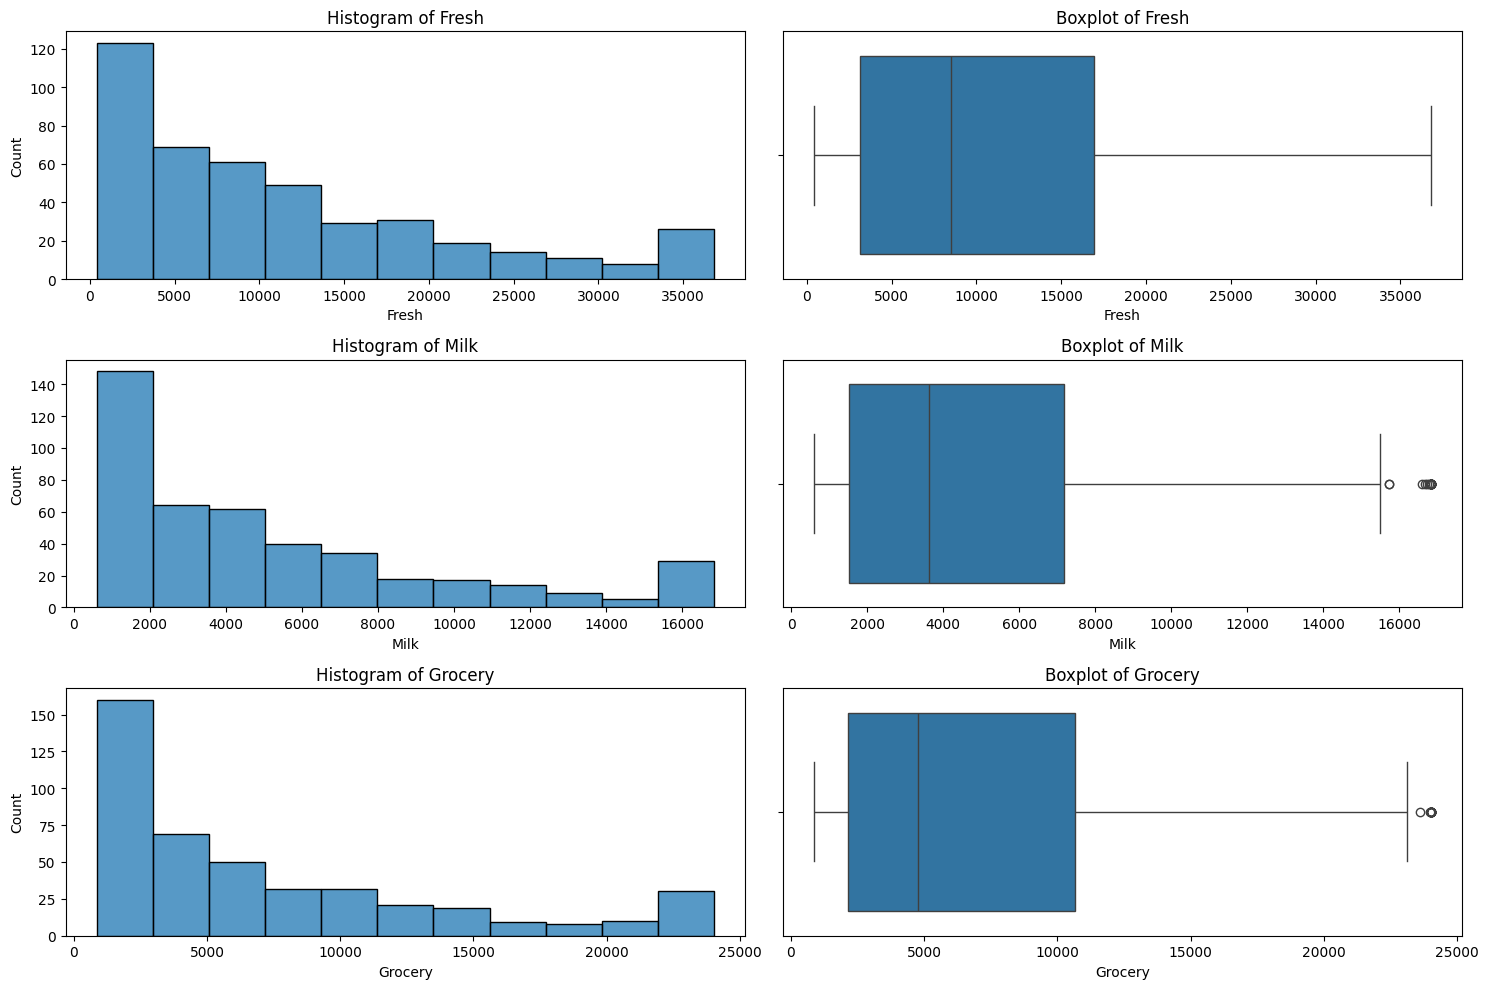

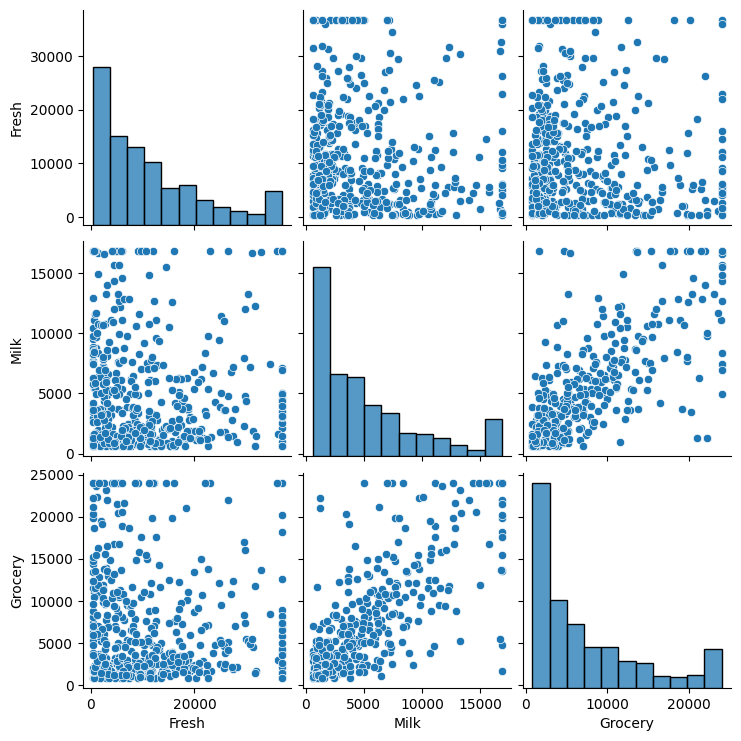

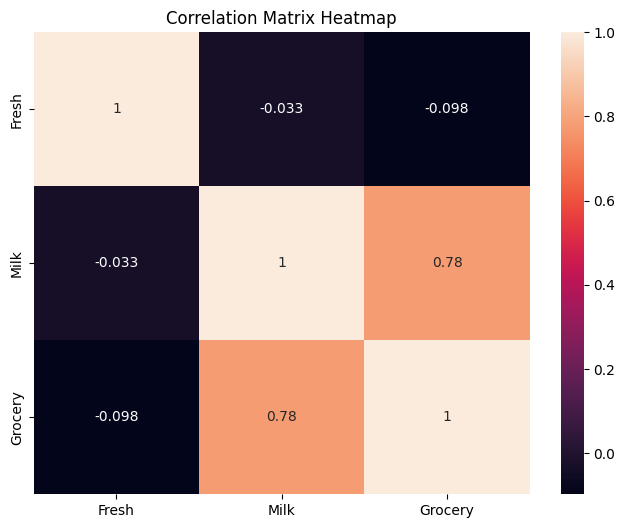

Channel Distribution:
 Channel
1    298
2    142
Name: count, dtype: int64

Region Distribution:
 Region
3    316
1     77
2     47
Name: count, dtype: int64


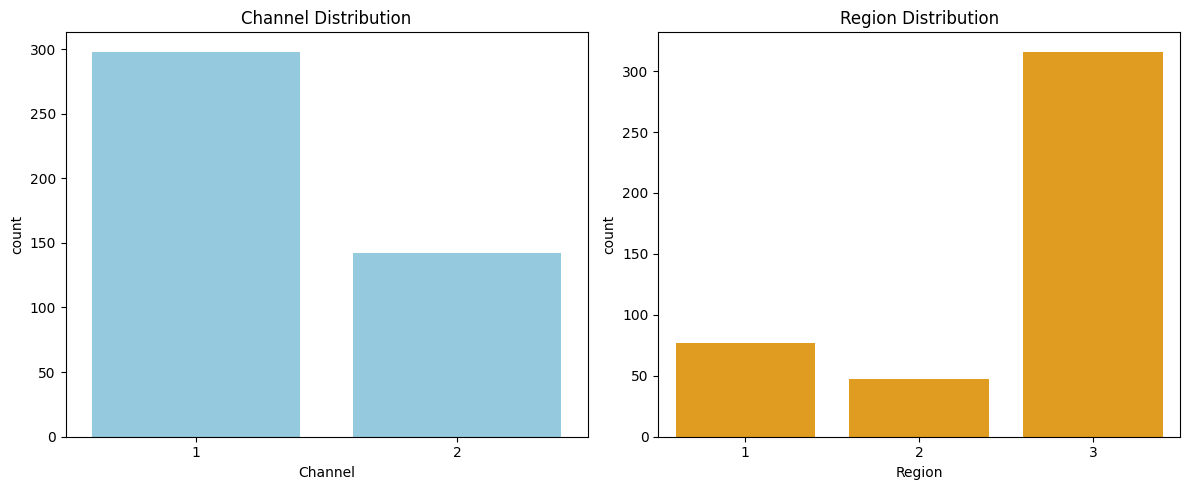

In [10]:

# 5. Insights and Conclusions: Visualizations
import matplotlib.pyplot as plt
# a) Histograms and box plots for numerical columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3, 2, 2*i - 1)
    sns.histplot(df[col])
    plt.title(f'Histogram of {col}')
    plt.subplot(3, 2, 2*i)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

# b) Scatter plot matrix to explore relationships
sns.pairplot(df[numerical_cols])
plt.show()

# c) Correlation matrix heatmap
plt.figure(figsize=(8,6))
corr_matrix = df[numerical_cols].corr()
sns.heatmap(corr_matrix,annot=True)
plt.title("Correlation Matrix Heatmap")
plt.show()

# d) Summary tables for categorical columns (class distribution)
# Summary tables for categorical columns
print("Channel Distribution:\n", df["Channel"].value_counts())
print("\nRegion Distribution:\n", df["Region"].value_counts())

# Visualize categorical distributions
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(x="Channel", data=df, color="skyblue")  # fixed
plt.title("Channel Distribution")

plt.subplot(1, 2, 2)
sns.countplot(x="Region", data=df, color="orange")  # fixed
plt.title("Region Distribution")

plt.tight_layout()
plt.show()




Use countplot → categorical variables (Channel, Region).
Use histplot → numerical variables (Fresh, Milk, Grocery, etc.).